# OT/ICS-IDS Paper Figures & Tables (v2 — polished)

This notebook regenerates **all paper artifacts** (LaTeX tables + publication-ready figures) from the CSV files produced by the main experiment notebook `ot_ics_ids_llm_nebius_v9.ipynb`.

It is **read-only**: it consumes CSVs and emits `.tex` + `.pdf`/`.png` files. No LLM calls, no model re-training.

## What it produces

**LaTeX tables**

- `paper_headline_table_binary.tex` — main results across 3 datasets × 4 methods (E7 multi-seed)
- `paper_mcnemar_table.tex` — paired McNemar significance tests
- `paper_wustl_multiclass_e7.tex` — WUSTL 5-class headline (the genuine multi-class case)
- `paper_perclass_wustl_multiclass.tex` — per-class F1 with bootstrap CIs
- `paper_master_table.csv` — long-format raw data

**Figures** (each saved as `.pdf` + `.png` at 300 dpi)

- `fig_forest_headline` — forest plot per metric across datasets (mean ± std)
- `fig_far_dr_pareto` — FAR vs DR with Pareto frontier
- `fig_mcnemar_heatmap` — paired sign(Δacc) × −log₁₀(p) heatmap
- `fig_wustl_perclass_radar` — per-class F1 radar (5 attack classes)
- `fig_cross_method_heatmap` — MCC heatmap dataset × method
- `fig_roc_overlays` — 3-panel ROC overlay across datasets

## How to use

1. Run cell 2 to install / upgrade packages (optional, most are standard).
2. Run cell 3 to declare the input directory layout.
3. Run cells 4 onward in order. Each section emits one or more artifacts to `OUT_DIR`.
4. Sections are independent: if you don't have a particular CSV, that section skips cleanly.


---

### Changelog from v1

- Forest plot: per-panel axis ranges (was shared, compressed HAI's range);
  cleaner legend, vertical dataset-mean markers.
- FAR-vs-DR Pareto: tightened WUSTL y-axis; added marker-shape legend.
- Cross-method heatmap: clearer best-per-row highlighting.
- k-shot curves: per-panel y-axis (WUSTL no longer flat-looking).
- Per-seed dispersion: switched from violin (misleading at n=3) to
  strip + mean line.
- AUROC/AUPRC bars: cleaner panel titles, tighter y-axis on saturated panels.

### New figures (v2)

- **`fig_cost_pareto`** — USD-cost-per-correct-prediction vs Macro-F1
  (LLM cost story, sourced from `e5_cost_<ds>.csv`).
- **`fig_r1_mannwhitney`** — Mann–Whitney heatmap: which LLMs significantly
  beat the RF baseline across 5 seeds, per dataset.
- **`fig_wustl_delta_vs_rf`** — Per-class F1 delta (LLM − RF) bar chart
  with bootstrap CIs and significance stars.


In [1]:
import os, glob, json, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# Publication style -- consistent across all figures
mpl.rcParams.update({
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.dpi":        110,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.30,
    "grid.linewidth":    0.5,
    "lines.linewidth":   1.5,
    "patch.linewidth":   0.6,
    "pdf.fonttype":      42,    # editable text in PDF (TrueType, not Type3)
    "ps.fonttype":       42,
})

# Per-method palette -- consistent across every figure
METHOD_PALETTE = {
    "Qwen3-235B-A22B": "#1f77b4",   # blue   — LLM
    "RandomForest":    "#d62728",   # red    — classical anchor
    "TabPFN":          "#2ca02c",   # green  — tabular FM 1
    "TabICL":          "#9467bd",   # purple — tabular FM 2
    "Llama-3.3-70B":   "#17becf",
    "Hermes-4-70B":    "#8c564b",
    "Hermes-4-405B":   "#e377c2",
    "Gemma-3-27B-it":  "#bcbd22",
}
DATASET_PALETTE = {
    "swat":  "#0072B2",
    "hai":   "#E69F00",
    "wustl": "#009E73",
}
METHOD_ORDER = ["Qwen3-235B-A22B", "RandomForest", "TabPFN", "TabICL"]
DATASET_ORDER = ["swat", "hai", "wustl"]
DATASET_LABEL = {"swat": "SWaT", "hai": "HAI", "wustl": "WUSTL"}

print("Style ready.")


Style ready.


## 1. Configure inputs and outputs

By default the notebook looks for CSVs inside `inputs/` (relative to the notebook). You can:

- Drop the contents of any `master_summary_<ds>.csv` + per-experiment subdirectories there.
- Or set `INPUT_DIRS` to point at the full output trees from your experiment runs (one per dataset/mode combination).

Each entry of `INPUT_DIRS` is `(dataset, mode, path)` where `mode` ∈ {`binary`, `multiclass`}.


In [4]:
# ============================================================
# 1b) UNZIP UPLOADED RUN ARCHIVES
# ============================================================
# Run this after uploading the six paper-grade run zips. It extracts each
# into a per-(dataset, mode) folder under ./runs/ so the INPUT_DIRS paths
# declared above resolve without any further edits.
import zipfile, shutil
from pathlib import Path

# Map of (dataset, mode) -> source-zip filename. Edit ZIP_DIR if your
# zips live somewhere other than the notebook's working directory.
ZIP_DIR = Path(".")
ZIP_MAP = {
    ("swat",  "binary")    : "ot_ics_ids_swat_paper_20260524_114047_swat.zip",
    ("hai",   "binary")    : "ot_ics_ids_hai_paper_20260524_094123_hai.zip",
    ("wustl", "binary")    : "ot_ics_ids_wustl_paper_20260524_075551_wustl.zip",
    ("swat",  "multiclass"): "ot_ics_ids_swat_paper_20260524_114040_multiclass_swat.zip",
    ("hai",   "multiclass"): "ot_ics_ids_hai_paper_20260524_114445_multiclass_hai.zip",
    ("wustl", "multiclass"): "ot_ics_ids_wustl_paper_20260524_152030_multiclass_wustl.zip",
}

RUNS_ROOT = Path("runs")
RUNS_ROOT.mkdir(exist_ok=True)

for (ds, mode), zip_name in ZIP_MAP.items():
    zip_path = ZIP_DIR / zip_name
    if not zip_path.exists():
        print(f"  [skip] {zip_name} not found in {ZIP_DIR.resolve()}")
        continue

    dest = RUNS_ROOT / f"{ds}_{mode}"
    # Clean up any previous extraction
    if dest.exists():
        shutil.rmtree(dest)
    dest.mkdir(parents=True)

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest)

    # Each zip contains an `ot_ics_ids_llm_nebius_v1_outputs/` directory
    # (sometimes nested one level deep). Locate it and flatten if needed.
    target_name = "ot_ics_ids_llm_nebius_v1_outputs"
    if (dest / target_name).is_dir():
        pass   # already in the right place
    else:
        found = next(dest.rglob(target_name), None)
        if found is None:
            print(f"  [warn] {zip_name}: no '{target_name}' folder found inside.")
            continue
        # Move it up to dest/<target_name>
        shutil.move(str(found), str(dest / target_name))

    n_files = sum(1 for _ in (dest / target_name).rglob("*") if _.is_file())
    print(f"  [ok]   {ds:<6} {mode:<10} -> {dest/target_name}  ({n_files} files)")

print("\nLayout ready. The INPUT_DIRS in cell §1 should now resolve correctly.")
print("\nVerification:")
for ds, md_, base in INPUT_DIRS:
    base_p = Path(base)
    ms = base_p / f"master_summary_{ds}.csv"
    print(f"  {ds:<6} {md_:<10}  base={'OK ' if base_p.exists() else 'NO '}  "
          f"master_summary={'OK' if ms.exists() else 'NO'}")

  [ok]   swat   binary     -> runs/swat_binary/ot_ics_ids_llm_nebius_v1_outputs  (95 files)
  [ok]   hai    binary     -> runs/hai_binary/ot_ics_ids_llm_nebius_v1_outputs  (64 files)
  [ok]   wustl  binary     -> runs/wustl_binary/ot_ics_ids_llm_nebius_v1_outputs  (33 files)
  [ok]   swat   multiclass -> runs/swat_multiclass/ot_ics_ids_llm_nebius_v1_outputs  (33 files)
  [ok]   hai    multiclass -> runs/hai_multiclass/ot_ics_ids_llm_nebius_v1_outputs  (33 files)
  [ok]   wustl  multiclass -> runs/wustl_multiclass/ot_ics_ids_llm_nebius_v1_outputs  (33 files)

Layout ready. The INPUT_DIRS in cell §1 should now resolve correctly.

Verification:
  swat   binary      base=OK   master_summary=OK
  hai    binary      base=OK   master_summary=OK
  wustl  binary      base=OK   master_summary=OK
  swat   multiclass  base=OK   master_summary=OK
  hai    multiclass  base=OK   master_summary=OK
  wustl  multiclass  base=OK   master_summary=OK


In [5]:
# ============================================================
# INPUT / OUTPUT CONFIGURATION
# ============================================================
# Edit this list to point at your run output directories. Each directory
# should contain a `master_summary_<dataset>.csv` at the top level plus the
# experiment subfolders (E1_cross_family/, E2_kshot/, ..., E7_full_test/,
# R1_multiseed/, R2_perclass_multiseed/).

# Default layout: paste all the unzipped run directories under `runs/`
# next to this notebook. If a path is missing the section that needs it
# is skipped automatically.
INPUT_DIRS = [
    # (dataset, mode, path_to_v1_outputs)
    ("swat",  "binary",     "runs/swat_binary/ot_ics_ids_llm_nebius_v1_outputs"),
    ("hai",   "binary",     "runs/hai_binary/ot_ics_ids_llm_nebius_v1_outputs"),
    ("wustl", "binary",     "runs/wustl_binary/ot_ics_ids_llm_nebius_v1_outputs"),
    ("swat",  "multiclass", "runs/swat_multiclass/ot_ics_ids_llm_nebius_v1_outputs"),
    ("hai",   "multiclass", "runs/hai_multiclass/ot_ics_ids_llm_nebius_v1_outputs"),
    ("wustl", "multiclass", "runs/wustl_multiclass/ot_ics_ids_llm_nebius_v1_outputs"),
]

OUT_DIR = Path("paper_artifacts")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _input_csv(dataset, mode, *parts):
    """Return Path to a CSV under the run tree for (dataset, mode), or None."""
    for ds, md_, base in INPUT_DIRS:
        if ds == dataset and md_ == mode:
            p = Path(base, *parts)
            if p.exists():
                return p
            return None
    return None

# Report what we can see
print(f"OUT_DIR: {OUT_DIR.resolve()}")
print("\nInput availability:")
for ds, md_, base in INPUT_DIRS:
    base_p = Path(base)
    if base_p.exists():
        ms = base_p / f"master_summary_{ds}.csv"
        print(f"  {ds:<6} {md_:<10}  base={'OK ' if base_p.exists() else 'NO '}  "
              f"master_summary={'OK' if ms.exists() else 'NO'}")
    else:
        print(f"  {ds:<6} {md_:<10}  base=NO  (path does not exist)")


OUT_DIR: /content/paper_artifacts

Input availability:
  swat   binary      base=OK   master_summary=OK
  hai    binary      base=OK   master_summary=OK
  wustl  binary      base=OK   master_summary=OK
  swat   multiclass  base=OK   master_summary=OK
  hai    multiclass  base=OK   master_summary=OK
  wustl  multiclass  base=OK   master_summary=OK


## 2. Load every available CSV

In [6]:
# ============================================================
# LOAD ALL AVAILABLE CSVs
# ============================================================
# We build a dict-of-dataframes keyed by (dataset, mode, kind).

LOADED = {}   # (dataset, mode, kind) -> DataFrame

def _try_load(dataset, mode, kind, *parts):
    p = _input_csv(dataset, mode, *parts)
    if p is None:
        return
    try:
        df = pd.read_csv(p)
        LOADED[(dataset, mode, kind)] = df
    except Exception as e:
        print(f"  [warn] {p}: {e}")

for ds, md_, base in INPUT_DIRS:
    if not Path(base).exists():
        continue
    _try_load(ds, md_, "master",            f"master_summary_{ds}.csv")
    _try_load(ds, md_, "e7_multiseed",      "E7_full_test", f"e7_multiseed_summary_{ds}.csv")
    _try_load(ds, md_, "e7_per_seed",       "E7_full_test", f"e7_per_seed_{ds}.csv")
    _try_load(ds, md_, "e7_paired_mcnemar", "E7_full_test", f"e7_paired_mcnemar_{ds}.csv")
    _try_load(ds, md_, "e7_auroc_auprc",    "E7_full_test", f"e7_auroc_auprc_{ds}.csv")
    _try_load(ds, md_, "e7_full_test",      "E7_full_test", f"e7_full_test_{ds}.csv")
    _try_load(ds, md_, "e1",                "E1_cross_family", f"e1_summary_{ds}.csv")
    _try_load(ds, md_, "e2",                "E2_kshot", f"e2_kshot_{ds}.csv")
    _try_load(ds, md_, "r1",                "R1_multiseed", f"r1_summary_{ds}.csv")
    _try_load(ds, md_, "r2",                "R2_perclass_multiseed", f"r2_perclass_{ds}.csv")

print(f"Loaded {len(LOADED)} CSVs:")
for k, df in sorted(LOADED.items()):
    print(f"  {k}  shape={df.shape}")


Loaded 60 CSVs:
  ('hai', 'binary', 'e1')  shape=(7, 12)
  ('hai', 'binary', 'e2')  shape=(20, 8)
  ('hai', 'binary', 'e7_auroc_auprc')  shape=(3, 4)
  ('hai', 'binary', 'e7_full_test')  shape=(4, 17)
  ('hai', 'binary', 'e7_multiseed')  shape=(4, 24)
  ('hai', 'binary', 'e7_paired_mcnemar')  shape=(3, 10)
  ('hai', 'binary', 'e7_per_seed')  shape=(12, 9)
  ('hai', 'binary', 'master')  shape=(39, 10)
  ('hai', 'binary', 'r1')  shape=(5, 18)
  ('hai', 'binary', 'r2')  shape=(10, 9)
  ('hai', 'multiclass', 'e1')  shape=(7, 12)
  ('hai', 'multiclass', 'e2')  shape=(20, 8)
  ('hai', 'multiclass', 'e7_auroc_auprc')  shape=(3, 4)
  ('hai', 'multiclass', 'e7_full_test')  shape=(4, 17)
  ('hai', 'multiclass', 'e7_multiseed')  shape=(4, 24)
  ('hai', 'multiclass', 'e7_paired_mcnemar')  shape=(3, 10)
  ('hai', 'multiclass', 'e7_per_seed')  shape=(12, 9)
  ('hai', 'multiclass', 'master')  shape=(39, 10)
  ('hai', 'multiclass', 'r1')  shape=(5, 18)
  ('hai', 'multiclass', 'r2')  shape=(10, 9)
  ('

## 3. Build the master long-format table

Concatenates all per-dataset `master_summary_<ds>.csv` files and tags every row with `mode`.
This is the canonical artifact other sections build from.


In [7]:
# ============================================================
# Long-format master table
# ============================================================
master_frames = []
for (ds, md_, kind), df in LOADED.items():
    if kind != "master":
        continue
    df = df.copy()
    df["mode"] = md_
    df["dataset"] = ds
    master_frames.append(df)

if master_frames:
    MASTER = pd.concat(master_frames, ignore_index=True)
    # Move dataset/mode to front
    cols = ["dataset", "mode"] + [c for c in MASTER.columns if c not in ("dataset","mode")]
    MASTER = MASTER[cols]
    csv_path = OUT_DIR / "paper_master_table.csv"
    MASTER.to_csv(csv_path, index=False)
    print(f"Wrote {csv_path}  ({len(MASTER)} rows, "
          f"{MASTER['experiment'].nunique()} experiments, "
          f"{MASTER['model'].nunique()} models)")
    display(MASTER.head(10))
else:
    print("No master_summary CSVs found. Subsequent sections will skip.")
    MASTER = pd.DataFrame()


Wrote paper_artifacts/paper_master_table.csv  (234 rows, 13 experiments, 7 models)


,dataset,mode,experiment,model,kind,accuracy,macro_f1,balanced_acc,MCC,FAR,DR
0,swat,binary,E1,Llama-3.3-70B,LLM,0.84,0.835796,0.84,0.717741,0.0,0.68
1,swat,binary,E1,Qwen3-235B-A22B,LLM,0.83,0.824941,0.83,0.701810,0.0,0.66
2,swat,binary,E1,Hermes-4-70B,LLM,0.70,0.696970,0.70,0.408248,0.4,0.80
3,swat,binary,E1,Hermes-4-405B,LLM,0.81,0.802884,0.81,0.670280,0.0,0.62
4,swat,binary,E1,RandomForest,Anchor,0.79,0.780312,0.79,0.639101,0.0,0.58
5,swat,binary,E1,TabPFN,Anchor,0.79,0.780312,0.79,0.639101,0.0,0.58
6,swat,binary,E1,TabICL,Anchor,0.82,0.813973,0.82,0.685994,0.0,0.64
7,swat,binary,E2_k5,Qwen3-235B-A22B,LLM,0.83,0.824941,NaN,0.701810,0.0,0.66
8,swat,binary,E2_k5,RandomForest,Anchor,0.79,0.780312,NaN,0.639101,0.0,0.58
9,swat,binary,E2_k5,TabPFN,Anchor,0.79,0.780312,NaN,0.639101,0.0,0.58


## 4. Headline table — E7 multi-seed across datasets

Drop-in `.tex` for the paper's main results table. Reports mean ± std across the 3 E7 seeds. Anchors are evaluated on the full holdout (~62k–100k rows); LLMs on the n=6000 stratified subsample.


In [8]:
# ============================================================
# Headline table (binary mode, since SWaT/HAI multiclass = binary)
# ============================================================
headline_frames = []
for (ds, md_, kind), df in LOADED.items():
    if kind != "e7_multiseed" or md_ != "binary":
        continue
    df = df.copy()
    df.insert(0, "dataset", ds)
    headline_frames.append(df)

if headline_frames:
    HEADLINE = pd.concat(headline_frames, ignore_index=True)
    HEADLINE = HEADLINE.sort_values(["dataset", "kind", "MCC_mean"],
                                     ascending=[True, True, False]).reset_index(drop=True)

    # Compute best-per-dataset for bolding
    best_mcc = HEADLINE.groupby("dataset")["MCC_mean"].transform("max")
    is_best  = (HEADLINE["MCC_mean"] == best_mcc)
    best_acc = HEADLINE.groupby("dataset")["accuracy_mean"].transform("max")
    is_best_acc = (HEADLINE["accuracy_mean"] == best_acc)

    def _fmt(val, std, bold=False):
        s = f"{val:.3f} $\\pm$ {std:.3f}"
        return ("\\textbf{" + s + "}") if bold else s

    tex = OUT_DIR / "paper_headline_table_binary.tex"
    n_seeds = int(HEADLINE["n_seeds"].iloc[0])
    with open(tex, "w") as f:
        f.write("% Headline table -- E7 multi-seed, binary classification\n")
        f.write("% LLM evaluated on n=6000 stratified subsample; anchors on FULL holdout.\n")
        f.write("\\begin{table}[t]\n\\centering\n")
        f.write("\\caption{Cross-dataset E7 multi-seed binary evaluation. "
                f"Values are mean $\\pm$ standard deviation across {n_seeds} seeds. "
                "Anchors are evaluated on the full held-out test set; "
                "the LLM on a stratified subsample of $n_{\\mathrm{LLM}}=6000$. "
                "Best per dataset (in MCC) is bolded.}\n")
        f.write("\\label{tab:headline}\n")
        f.write("\\small\n\\begin{tabular}{llrrrrr}\n\\toprule\n")
        f.write("Dataset & Model & Acc. & Macro F1 & MCC & FAR & DR \\\\\n")
        f.write("\\midrule\n")
        last_ds = None
        for i, r in HEADLINE.iterrows():
            if last_ds is not None and r["dataset"] != last_ds:
                f.write("\\midrule\n")
            last_ds = r["dataset"]
            bold = bool(is_best.iloc[i])
            acc_str = _fmt(r["accuracy_mean"], r["accuracy_std"], bold)
            f1_str  = _fmt(r["macro_f1_mean"], r["macro_f1_std"])
            mcc_str = _fmt(r["MCC_mean"],      r["MCC_std"],      bold)
            far_str = _fmt(r["FAR_mean"],      r["FAR_std"])
            dr_str  = _fmt(r["DR_mean"],       r["DR_std"])
            f.write(f"{DATASET_LABEL[r['dataset']]} & {r['model']} & "
                    f"{acc_str} & {f1_str} & {mcc_str} & {far_str} & {dr_str} \\\\\n")
        f.write("\\bottomrule\n\\end{tabular}\n\\end{table}\n")
    print(f"Wrote {tex}")
    display(HEADLINE[["dataset","model","kind","accuracy_mean","accuracy_std",
                       "MCC_mean","MCC_std","FAR_mean","DR_mean"]].round(4))
else:
    HEADLINE = pd.DataFrame()
    print("No e7_multiseed CSVs found; skipping headline table.")


Wrote paper_artifacts/paper_headline_table_binary.tex


,dataset,model,kind,accuracy_mean,accuracy_std,MCC_mean,MCC_std,FAR_mean,DR_mean
0,hai,TabICL,Anchor,0.7330,0.0186,0.4324,0.0133,0.2883,0.8216
1,hai,RandomForest,Anchor,0.7066,0.0139,0.4127,0.0137,0.3259,0.8419
2,hai,TabPFN,Anchor,0.6835,0.0061,0.4065,0.0099,0.3626,0.8752
3,hai,Qwen3-235B-A22B,LLM,0.6896,0.0030,0.3499,0.0116,0.3284,0.7641
4,swat,RandomForest,Anchor,0.8270,0.0010,0.6952,0.0019,0.0033,0.6572
5,swat,TabICL,Anchor,0.8181,0.0013,0.6713,0.0032,0.0223,0.6585
6,swat,TabPFN,Anchor,0.8052,0.0004,0.6270,0.0013,0.0802,0.6906
7,swat,Qwen3-235B-A22B,LLM,0.8364,0.0033,0.6998,0.0054,0.0261,0.6989
8,wustl,TabPFN,Anchor,0.9878,0.0001,0.9757,0.0002,0.0224,0.9980
9,wustl,TabICL,Anchor,0.9855,0.0004,0.9713,0.0008,0.0281,0.9990


## 5. Forest plot — per-metric, per-dataset

A four-panel forest plot (Accuracy, Macro F1, MCC, DR) with error bars showing ±1σ across the E7 seeds. This is the **most informative single figure** for the paper: a reader sees the full cross-method, cross-dataset story at a glance.


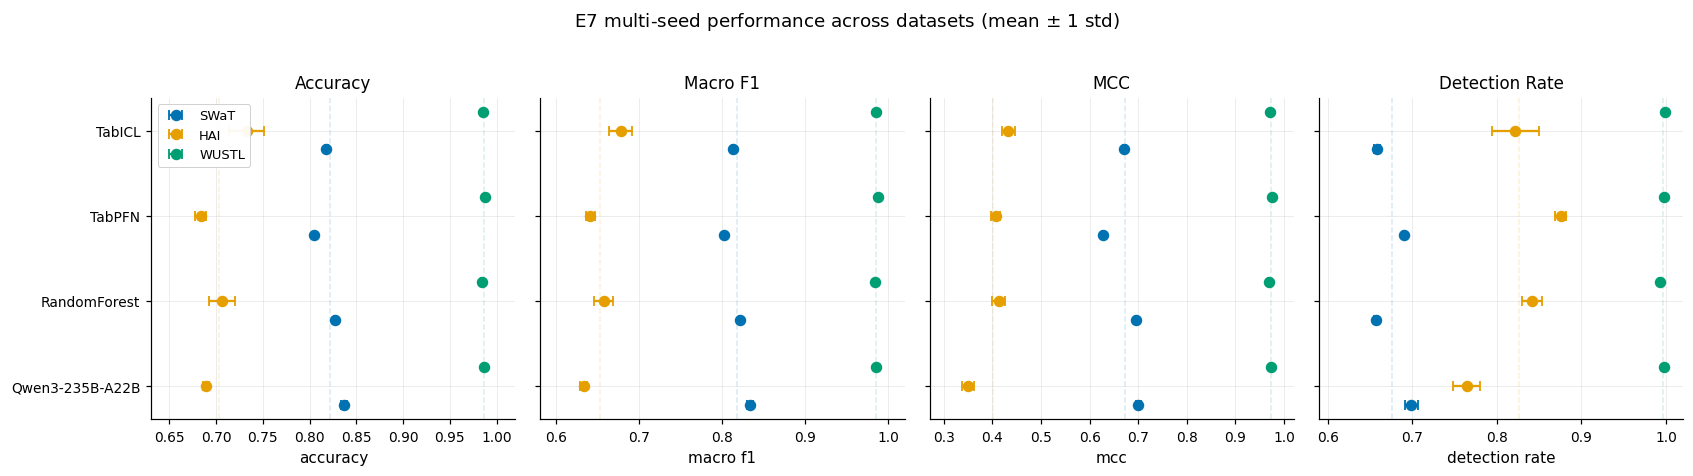

Wrote fig_forest_headline.{pdf,png}


In [9]:
# ============================================================
# Figure 1: forest plot -- v2 (per-panel ranges, cleaner legend)
# ============================================================
if not HEADLINE.empty:
    metrics = [("accuracy_mean", "accuracy_std", "Accuracy"),
               ("macro_f1_mean", "macro_f1_std", "Macro F1"),
               ("MCC_mean",      "MCC_std",      "MCC"),
               ("DR_mean",       "DR_std",       "Detection Rate")]

    methods = [m for m in METHOD_ORDER
                if m in HEADLINE["model"].unique()]
    datasets = [d for d in DATASET_ORDER
                if d in HEADLINE["dataset"].unique()]
    n_methods  = len(methods)
    n_datasets = len(datasets)

    # v2: each metric panel has its own x-range (computed below)
    fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.2), sharey=True)

    for ax, (mean_c, std_c, title) in zip(axes, metrics):
        # Compute panel-specific x-range with a 10% pad on each side
        col_min = HEADLINE[mean_c].min() - HEADLINE[std_c].max()
        col_max = HEADLINE[mean_c].max() + HEADLINE[std_c].max()
        pad = max(0.01, (col_max - col_min) * 0.10)
        ax.set_xlim(max(0.0, col_min - pad), min(1.02, col_max + pad))

        # Per-method block: 3 vertically-stacked points (one per dataset)
        y_base = np.arange(n_methods) * (n_datasets + 1) * 0.4
        for di, ds in enumerate(datasets):
            sub = HEADLINE[HEADLINE["dataset"] == ds].set_index("model")
            means = []
            stds = []
            for mname in methods:
                if mname in sub.index:
                    means.append(sub.loc[mname, mean_c])
                    stds.append(sub.loc[mname, std_c])
                else:
                    means.append(np.nan); stds.append(0.0)
            ys = y_base + di * 0.35
            ax.errorbar(means, ys, xerr=stds,
                         fmt="o", capsize=3, capthick=1.2,
                         markersize=6.5,
                         color=DATASET_PALETTE[ds],
                         ecolor=DATASET_PALETTE[ds],
                         label=DATASET_LABEL[ds] if ax is axes[0] else None,
                         zorder=3)
            # Faint vertical line at dataset mean (across methods)
            ds_mean = np.nanmean([m for m in means if not np.isnan(m)])
            ax.axvline(ds_mean, color=DATASET_PALETTE[ds],
                        alpha=0.15, linestyle="--", linewidth=1.0, zorder=1)

        ax.set_yticks(y_base + 0.35 * (n_datasets - 1) / 2)
        ax.set_yticklabels(methods)
        ax.invert_yaxis()
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(title.lower())
        ax.grid(axis="x", alpha=0.3)

    axes[0].legend(loc="upper left", frameon=True, framealpha=0.95,
                    fontsize=8.5, title=None)
    fig.suptitle("E7 multi-seed performance across datasets (mean $\\pm$ 1 std)",
                 y=1.02, fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_forest_headline.pdf")
    plt.savefig(OUT_DIR / "fig_forest_headline.png")
    plt.show()
    print(f"Wrote fig_forest_headline.{{pdf,png}}")


## 6. FAR vs DR Pareto front

Each method × dataset is one point in (FAR, DR) space. The **Pareto frontier** is the lower-right envelope — points that no other method dominates simultaneously on both axes. For OT/ICS deployment this is the actionable visualization: an operator picks a point on the frontier based on FAR tolerance.


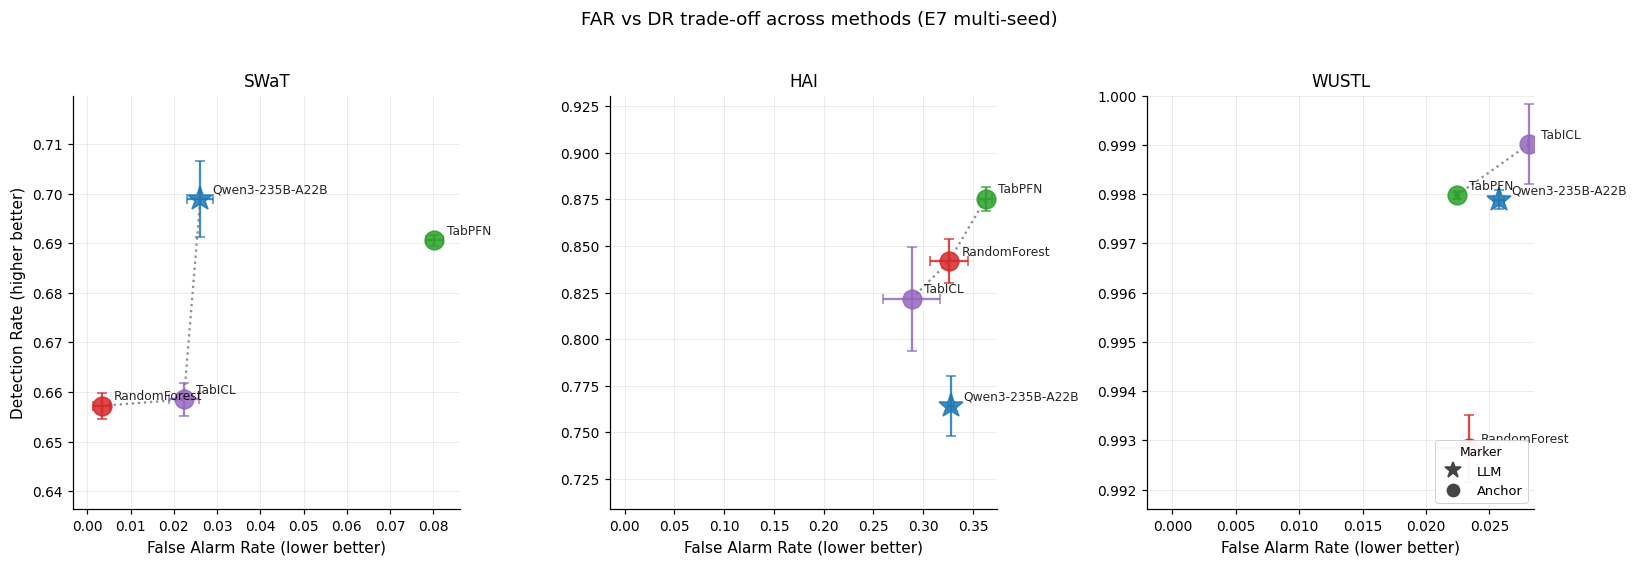

Wrote fig_far_dr_pareto.{pdf,png}


In [10]:
# ============================================================
# Figure 2: FAR vs DR Pareto front (per dataset) -- v2
# ============================================================
if not HEADLINE.empty:
    fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(15, 5), sharey=False)
    if len(DATASET_ORDER) == 1:
        axes = [axes]

    for ax, ds in zip(axes, DATASET_ORDER):
        sub = HEADLINE[HEADLINE["dataset"] == ds]
        if sub.empty:
            ax.set_visible(False); continue
        for _, r in sub.iterrows():
            color = METHOD_PALETTE.get(r["model"], "#888")
            marker = "*" if r["kind"] == "LLM" else "o"
            size   = 280 if r["kind"] == "LLM" else 150
            ax.errorbar(r["FAR_mean"], r["DR_mean"],
                         xerr=r["FAR_std"], yerr=r["DR_std"],
                         fmt=marker, markersize=np.sqrt(size),
                         color=color, ecolor=color, capsize=3, alpha=0.85,
                         label=r["model"])
            ax.annotate(r["model"], (r["FAR_mean"], r["DR_mean"]),
                         xytext=(8, 4), textcoords="offset points",
                         fontsize=8, alpha=0.85)
        # Pareto frontier (max DR for each lower-FAR cutoff)
        pts = sub[["FAR_mean","DR_mean","model"]].copy().sort_values("FAR_mean")
        frontier = []
        best_dr = -1
        for _, r in pts.iterrows():
            if r["DR_mean"] > best_dr:
                frontier.append((r["FAR_mean"], r["DR_mean"]))
                best_dr = r["DR_mean"]
        if len(frontier) >= 2:
            fx, fy = zip(*frontier)
            ax.plot(fx, fy, ":", color="#333", alpha=0.55,
                     linewidth=1.5, label="Pareto frontier", zorder=1)
        ax.set_xlabel("False Alarm Rate (lower better)")
        ax.set_ylabel("Detection Rate (higher better)" if ds == DATASET_ORDER[0] else "")
        ax.set_title(f"{DATASET_LABEL[ds]}", fontsize=11)
        ax.grid(alpha=0.3)
        # v2: tighter y-axis at saturation
        dr_max = sub["DR_mean"].max()
        dr_min = sub["DR_mean"].min()
        dr_span = max(0.005, dr_max - dr_min)
        if dr_max > 0.97:
            ax.set_ylim(max(0.0, dr_min - 0.2*dr_span), 1.0)
        else:
            ax.set_ylim(max(0.0, dr_min - 0.5*dr_span), min(1.0, dr_max + 0.5*dr_span))
        # Tighter x-axis when FAR is small everywhere
        far_max = sub["FAR_mean"].max()
        ax.set_xlim(left=-max(0.002, far_max * 0.04))

    # v2: marker-shape legend (LLM = star, anchor = circle) in lower-right of last panel
    from matplotlib.lines import Line2D
    shape_handles = [
        Line2D([0], [0], marker="*", color="#444", markersize=11,
                linestyle="None", label="LLM"),
        Line2D([0], [0], marker="o", color="#444", markersize=8,
                linestyle="None", label="Anchor"),
    ]
    axes[-1].legend(handles=shape_handles, loc="lower right",
                     fontsize=8.5, frameon=True, framealpha=0.95,
                     title="Marker", title_fontsize=8)

    fig.suptitle("FAR vs DR trade-off across methods (E7 multi-seed)",
                 y=1.02, fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_far_dr_pareto.pdf")
    plt.savefig(OUT_DIR / "fig_far_dr_pareto.png")
    plt.show()
    print(f"Wrote fig_far_dr_pareto.{{pdf,png}}")


## 7. Paired McNemar tests

For each (dataset, anchor), the LLM is compared to the anchor on the **exact same** 6000-sample LLM subsample. The 2×2 disagreement table is built from `(LLM right, anchor right)` etc., and McNemar's test is applied.

Two outputs:
- `paper_mcnemar_table.tex` — paper-ready table
- `fig_mcnemar_heatmap.{pdf,png}` — heatmap of sign(Δacc) × −log₁₀(p), red where LLM loses, green where LLM wins, intensity ∝ significance


Wrote paper_artifacts/paper_mcnemar_table.tex


,dataset,llm,anchor,delta_acc,llm_correct_anchor_wrong,anchor_correct_llm_wrong,mcnemar_p
0,hai,Qwen3-235B-A22B,RandomForest,-0.036500,253,472,5.664821e-16
1,hai,Qwen3-235B-A22B,TabICL,-0.072333,262,696,1.804365e-44
2,hai,Qwen3-235B-A22B,TabPFN,-0.000667,428,432,9.185192e-01
3,swat,Qwen3-235B-A22B,RandomForest,0.008333,137,87,1.060553e-03
4,swat,Qwen3-235B-A22B,TabICL,0.017500,228,123,2.838625e-08
5,swat,Qwen3-235B-A22B,TabPFN,0.032167,364,171,1.033397e-16
6,wustl,Qwen3-235B-A22B,RandomForest,0.002667,18,2,4.024506e-04
7,wustl,Qwen3-235B-A22B,TabICL,0.001167,15,8,2.100396e-01
8,wustl,Qwen3-235B-A22B,TabPFN,0.001000,20,14,3.911725e-01


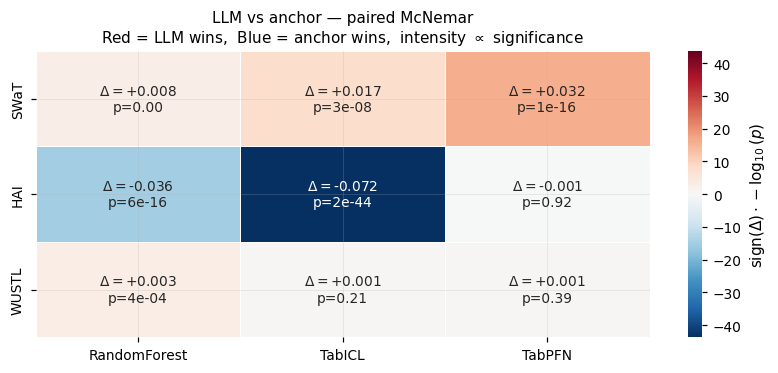

Wrote fig_mcnemar_heatmap.{pdf,png}


In [11]:
# ============================================================
# McNemar table + heatmap
# ============================================================
mc_frames = []
for (ds, md_, kind), df in LOADED.items():
    if kind != "e7_paired_mcnemar" or md_ != "binary":
        continue
    df = df.copy()
    df.insert(0, "dataset", ds)
    mc_frames.append(df)

if mc_frames:
    MCNEMAR = pd.concat(mc_frames, ignore_index=True)
    MCNEMAR = MCNEMAR.sort_values(["dataset", "anchor"]).reset_index(drop=True)

    # --- LaTeX ---
    tex = OUT_DIR / "paper_mcnemar_table.tex"
    with open(tex, "w") as f:
        f.write("% Paired McNemar tests on the n=6000 LLM subsample.\n")
        f.write("\\begin{table}[t]\n\\centering\n")
        f.write("\\caption{Paired McNemar tests for the LLM versus each anchor "
                "on the identical $n=6000$ E7 LLM subsample. "
                "$b$ is the number of samples where the LLM is correct and the "
                "anchor is wrong; $c$ the reverse. "
                "Significant differences ($p<0.05$) marked with $^{*}$.}\n")
        f.write("\\label{tab:mcnemar}\n")
        f.write("\\small\n\\begin{tabular}{lllrrrl}\n\\toprule\n")
        f.write("Dataset & LLM & Anchor & $\\Delta$acc & $b$ (LLM only) & $c$ (anc only) & $p$ \\\\\n")
        f.write("\\midrule\n")
        last_ds = None
        for _, r in MCNEMAR.iterrows():
            if last_ds is not None and r["dataset"] != last_ds:
                f.write("\\midrule\n")
            last_ds = r["dataset"]
            p = r["mcnemar_p"]
            p_str = (f"{p:.2e}" if (not pd.isna(p) and p < 0.01)
                     else f"{p:.3f}" if not pd.isna(p) else "n/a")
            sig = "$^{*}$" if (not pd.isna(p) and p < 0.05) else ""
            f.write(
                f"{DATASET_LABEL[r['dataset']]} & {r['llm']} & {r['anchor']} & "
                f"{r['delta_acc']:+.3f} & {int(r['llm_correct_anchor_wrong'])} & "
                f"{int(r['anchor_correct_llm_wrong'])} & {p_str}{sig} \\\\\n"
            )
        f.write("\\bottomrule\n\\end{tabular}\n\\end{table}\n")
    print(f"Wrote {tex}")
    display(MCNEMAR[["dataset","llm","anchor","delta_acc",
                      "llm_correct_anchor_wrong","anchor_correct_llm_wrong","mcnemar_p"]])

    # --- Heatmap ---
    anchors = sorted(MCNEMAR["anchor"].unique())
    datasets = [d for d in DATASET_ORDER if d in MCNEMAR["dataset"].unique()]
    matrix = np.zeros((len(datasets), len(anchors)))
    annot = [["" for _ in anchors] for _ in datasets]
    for i, ds in enumerate(datasets):
        for j, anc in enumerate(anchors):
            row = MCNEMAR[(MCNEMAR["dataset"]==ds) & (MCNEMAR["anchor"]==anc)]
            if row.empty:
                matrix[i,j] = np.nan
                annot[i][j] = "—"
                continue
            r = row.iloc[0]
            delta = r["delta_acc"]
            p = r["mcnemar_p"]
            sign = 1.0 if delta >= 0 else -1.0
            # log-scale magnitude (cap at 50 to keep colours readable)
            mag = min(-math.log10(max(p, 1e-50)), 50)
            matrix[i,j] = sign * mag
            p_short = f"{p:.0e}" if p < 0.001 else f"{p:.2f}"
            annot[i][j] = f"$\\Delta=${delta:+.3f}\np={p_short}"

    fig, ax = plt.subplots(figsize=(7.5, 3.5))
    vmax = max(abs(np.nanmin(matrix)), abs(np.nanmax(matrix)), 1.0)
    sns.heatmap(matrix, annot=annot, fmt="",
                xticklabels=anchors,
                yticklabels=[DATASET_LABEL[d] for d in datasets],
                cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                linewidths=0.6, ax=ax, cbar_kws={"label": "$\\mathrm{sign}(\\Delta) \\cdot -\\log_{10}(p)$"},
                annot_kws={"fontsize":9})
    ax.set_title("LLM vs anchor — paired McNemar\nRed = LLM wins,  Blue = anchor wins,  intensity $\\propto$ significance",
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_mcnemar_heatmap.pdf")
    plt.savefig(OUT_DIR / "fig_mcnemar_heatmap.png")
    plt.show()
    print(f"Wrote fig_mcnemar_heatmap.{{pdf,png}}")
else:
    MCNEMAR = pd.DataFrame()
    print("No e7_paired_mcnemar CSVs found.")


## 8. WUSTL multiclass — the genuine 5-class case

SWaT and HAI Kaggle mirrors carry only a binary `Normal/Attack` label, so v8's `BINARY_LABELS=False` runs on those datasets degraded to binary. **WUSTL is the only dataset with genuine multi-class labels** (5 classes: `Backdoor`, `CommInj`, `DoS`, `Normal`, `Reconn`).


In [12]:
# ============================================================
# WUSTL multiclass headline + per-class
# ============================================================
wustl_mc = LOADED.get(("wustl", "multiclass", "e7_multiseed"))
wustl_r2 = LOADED.get(("wustl", "multiclass", "r2"))

if wustl_mc is not None:
    wmc = wustl_mc.sort_values(["kind", "MCC_mean"], ascending=[True, False]).reset_index(drop=True)
    tex = OUT_DIR / "paper_wustl_multiclass_e7.tex"
    with open(tex, "w") as f:
        f.write("% WUSTL multi-class (5 classes) -- E7 multi-seed (3 seeds)\n")
        f.write("\\begin{table}[t]\n\\centering\n")
        f.write("\\caption{Genuine multi-class evaluation on WUSTL-IIoT-2021 "
                "(5 classes: \\textsf{Backdoor}, \\textsf{CommInj}, "
                "\\textsf{DoS}, \\textsf{Normal}, \\textsf{Reconn}). "
                f"Mean $\\pm$ std across {int(wmc['n_seeds'].iloc[0])} seeds.}}\n")
        f.write("\\label{tab:wustl-mc}\n\\small\n")
        f.write("\\begin{tabular}{llrrr}\n\\toprule\n")
        f.write("Model & Kind & Accuracy & Macro F1 & MCC \\\\\n\\midrule\n")
        for _, r in wmc.iterrows():
            f.write(
                f"{r['model']} & {r['kind']} & "
                f"{r['accuracy_mean']:.3f} $\\pm$ {r['accuracy_std']:.3f} & "
                f"{r['macro_f1_mean']:.3f} $\\pm$ {r['macro_f1_std']:.3f} & "
                f"{r['MCC_mean']:.3f} $\\pm$ {r['MCC_std']:.3f} \\\\\n"
            )
        f.write("\\bottomrule\n\\end{tabular}\n\\end{table}\n")
    print(f"Wrote {tex}")
    display(wmc[["model","kind","accuracy_mean","accuracy_std","macro_f1_mean","MCC_mean"]].round(4))

if wustl_r2 is not None:
    # Build the per-class LaTeX table fresh from r2_perclass CSV
    r2 = wustl_r2.copy()
    classes = sorted(r2["class"].unique())
    models  = sorted(r2["model"].unique())
    # Pivot
    pivot = r2.pivot(index="model", columns="class",
                      values=["f1_mean", "f1_lo", "f1_hi"])
    tex = OUT_DIR / "paper_perclass_wustl_multiclass.tex"
    with open(tex, "w") as f:
        f.write("% Per-class F1 with bootstrap 95% CIs on WUSTL multi-class\n")
        f.write("\\begin{table}[t]\n\\centering\n")
        f.write("\\caption{Per-class F1 on WUSTL-IIoT-2021 multi-class "
                "(bootstrap 95\\% CIs across "
                f"{int(r2['n_seeds'].iloc[0])} seeds). Macro is the unweighted mean across classes.}}\n")
        f.write("\\label{tab:wustl-perclass}\n\\small\n")
        f.write("\\setlength{\\tabcolsep}{4pt}\n")
        ncols = len(classes) + 2  # model + classes + macro
        f.write("\\begin{tabular}{l" + "c"*(ncols-1) + "}\n\\toprule\n")
        f.write("Model & " + " & ".join(classes) + " & Macro \\\\\n\\midrule\n")
        for m in models:
            row = [m]
            f1s = []
            for c in classes:
                mu  = pivot["f1_mean"].loc[m, c]
                lo  = pivot["f1_lo"].loc[m, c]
                hi  = pivot["f1_hi"].loc[m, c]
                row.append(f"{mu:.3f}\\,[{lo:.3f},\\,{hi:.3f}]")
                f1s.append(mu)
            row.append(f"{np.mean(f1s):.3f}")
            f.write(" & ".join(row) + " \\\\\n")
        f.write("\\bottomrule\n\\end{tabular}\n\\end{table}\n")
    print(f"Wrote {tex}")


Wrote paper_artifacts/paper_wustl_multiclass_e7.tex


,model,kind,accuracy_mean,accuracy_std,macro_f1_mean,MCC_mean
0,TabPFN,Anchor,0.9916,0.0003,0.9245,0.9854
1,RandomForest,Anchor,0.9878,0.0006,0.8830,0.9788
2,TabICL,Anchor,0.9863,0.0010,0.8616,0.9761
3,Qwen3-235B-A22B,LLM,0.9812,0.0039,0.8053,0.9674


Wrote paper_artifacts/paper_perclass_wustl_multiclass.tex


## 9. WUSTL per-class radar plot

A radar plot showing per-class F1 across all 5 attack types. Anchors usually form a 'fat' shape (uniformly strong); LLMs form a 'pointy' shape (asymmetric strength). The pointiness on DoS / Reconn is the central finding.


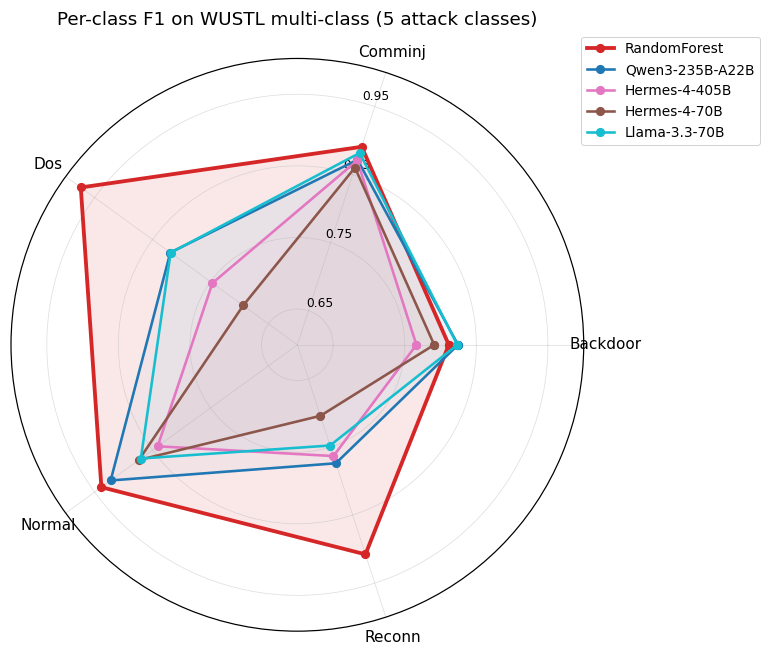

Wrote fig_wustl_perclass_radar.{pdf,png}


In [13]:
# ============================================================
# Figure 3: WUSTL per-class radar
# ============================================================
if wustl_r2 is not None:
    r2 = wustl_r2
    classes = sorted(r2["class"].unique())
    models  = list(r2["model"].unique())
    # Order: anchors first, LLMs in METHOD_ORDER order
    anchor_models = [m for m in models if m == "RandomForest"]
    llm_models    = [m for m in METHOD_ORDER if m in models and m != "RandomForest"]
    other_llms    = [m for m in models if m not in anchor_models + llm_models]
    plot_order    = anchor_models + llm_models + other_llms

    n_classes = len(classes)
    angles = np.linspace(0, 2*np.pi, n_classes, endpoint=False).tolist()
    angles += angles[:1]   # close

    fig, ax = plt.subplots(figsize=(7.2, 7.2), subplot_kw=dict(polar=True))
    for m in plot_order:
        sub = r2[r2["model"] == m].set_index("class").reindex(classes)
        vals = sub["f1_mean"].values.tolist()
        vals_closed = vals + vals[:1]
        color = METHOD_PALETTE.get(m, "#888")
        lw = 2.5 if m == "RandomForest" else 1.7
        ls = "-"
        alpha_fill = 0.10 if m == "RandomForest" else 0.04
        ax.plot(angles, vals_closed, ls, lw=lw, color=color, label=m,
                 marker="o", markersize=5)
        ax.fill(angles, vals_closed, color=color, alpha=alpha_fill)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(classes, fontsize=10)
    ax.set_ylim(0.6, 1.0)
    ax.set_rlabel_position(75)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_yticks([0.65, 0.75, 0.85, 0.95])
    ax.set_yticklabels(["0.65", "0.75", "0.85", "0.95"])
    ax.grid(alpha=0.4)
    ax.set_title("Per-class F1 on WUSTL multi-class (5 attack classes)",
                  pad=22, fontsize=12)
    ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.05),
               frameon=True, framealpha=0.95)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_wustl_perclass_radar.pdf")
    plt.savefig(OUT_DIR / "fig_wustl_perclass_radar.png")
    plt.show()
    print(f"Wrote fig_wustl_perclass_radar.{{pdf,png}}")


## 10. Cross-method MCC heatmap

A compact summary: rows = datasets, columns = methods, cells = MCC mean ± std. The colour bar makes the dataset-dependence of method ranking visually obvious.


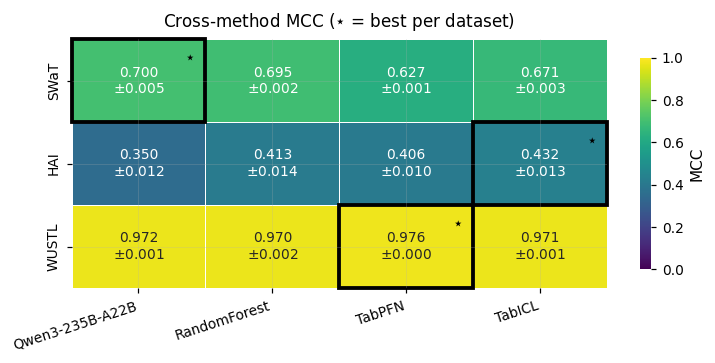

Wrote fig_cross_method_heatmap.{pdf,png}


In [14]:
# ============================================================
# Figure 4: cross-method MCC heatmap -- v2 (clearer best-per-row)
# ============================================================
if not HEADLINE.empty:
    pivot_mean = HEADLINE.pivot(index="dataset", columns="model", values="MCC_mean")
    pivot_std  = HEADLINE.pivot(index="dataset", columns="model", values="MCC_std")
    pivot_mean = pivot_mean.reindex(index=DATASET_ORDER, columns=METHOD_ORDER)
    pivot_std  = pivot_std.reindex (index=DATASET_ORDER, columns=METHOD_ORDER)
    pivot_mean = pivot_mean.dropna(how="all").dropna(axis=1, how="all")
    pivot_std  = pivot_std.reindex_like(pivot_mean)

    annot = np.empty_like(pivot_mean.values, dtype=object)
    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            mu = pivot_mean.values[i, j]
            sd = pivot_std.values[i, j]
            annot[i, j] = "—" if np.isnan(mu) else f"{mu:.3f}\n$\\pm${sd:.3f}"

    fig, ax = plt.subplots(figsize=(7, 3.4))
    sns.heatmap(pivot_mean, annot=annot, fmt="",
                 cmap="viridis", vmin=0.0, vmax=1.0,
                 xticklabels=pivot_mean.columns,
                 yticklabels=[DATASET_LABEL[d] for d in pivot_mean.index],
                 linewidths=0.5, linecolor="white", ax=ax,
                 cbar_kws={"label": "MCC", "shrink": 0.85},
                 annot_kws={"fontsize":9, "fontweight":"normal"})

    # v2: thick black border on best-per-row cell; star marker overlay top-left
    for i in range(pivot_mean.shape[0]):
        row = pivot_mean.values[i]
        if np.isnan(row).all(): continue
        j_best = np.nanargmax(row)
        # Bold black border
        ax.add_patch(plt.Rectangle((j_best, i), 1, 1, fill=False,
                                    edgecolor="black", lw=2.5, clip_on=False))
        # Star marker in the corner
        ax.text(j_best + 0.92, i + 0.10, "$\\star$",
                 fontsize=11, color="black", ha="right", va="top",
                 fontweight="bold")

    ax.set_title("Cross-method MCC ($\\star$ = best per dataset)",
                  fontsize=11, pad=8)
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=18, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_cross_method_heatmap.pdf")
    plt.savefig(OUT_DIR / "fig_cross_method_heatmap.png")
    plt.show()
    print(f"Wrote fig_cross_method_heatmap.{{pdf,png}}")


## 11. AUROC / AUPRC summary — 3-panel cross-dataset bars

Three side-by-side panels (one per dataset) summarising the anchors' AUROC and AUPRC. The LLM has no calibrated probability so it is omitted, following the OT/ICS literature convention (Goh 2017, Kravchik 2018, Shin 2020).

If `e7_auroc_auprc_<ds>.csv` is available, the panel shows AUROC and AUPRC side-by-side as bars (raw `predict_proba` arrays are not saved by the experiment notebook, so we use the scalar summary).


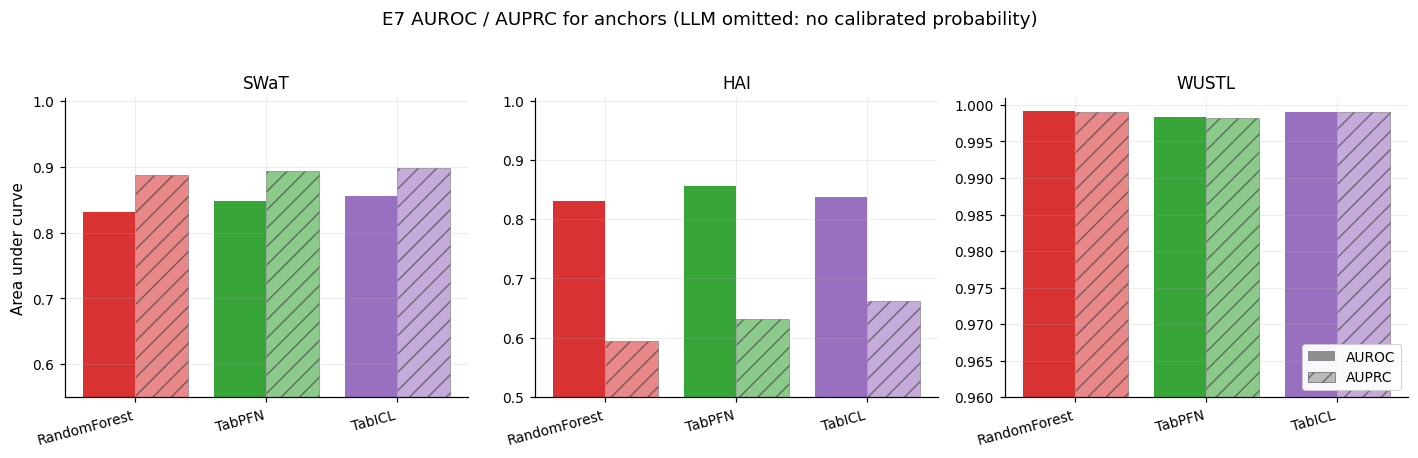

Wrote fig_auroc_auprc_bars.{pdf,png}


In [15]:
# ============================================================
# Figure 5: AUROC/AUPRC bars -- v2 (cleaner panels, zoomed y-axis at saturation)
# ============================================================
fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(13, 4))
if len(DATASET_ORDER) == 1:
    axes = [axes]

drew_any = False
for ax, ds in zip(axes, DATASET_ORDER):
    auroc_df = LOADED.get((ds, "binary", "e7_auroc_auprc"))
    if auroc_df is None or auroc_df.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center",
                 transform=ax.transAxes, color="#666")
        ax.set_title(DATASET_LABEL[ds]); continue

    models = list(auroc_df["model"])
    aurocs = list(auroc_df["AUROC"])
    auprcs = list(auroc_df["AUPRC"])
    x = np.arange(len(models))
    width = 0.4
    for i, mname in enumerate(models):
        color = METHOD_PALETTE.get(mname, "#888")
        ax.bar(x[i] - width/2, aurocs[i], width=width, color=color, alpha=0.95)
        ax.bar(x[i] + width/2, auprcs[i], width=width, color=color, alpha=0.55,
                hatch="//", edgecolor="#333", linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Area under curve" if ax is axes[0] else "")
    ax.set_title(DATASET_LABEL[ds], fontsize=11)
    # v2: zoom into the actually-relevant range
    y_lo = min(min(aurocs), min(auprcs))
    y_hi = max(max(aurocs), max(auprcs))
    if y_lo > 0.96:
        ax.set_ylim(0.96, 1.001)
    elif y_lo > 0.7:
        ax.set_ylim(0.55, 1.005)
    else:
        ax.set_ylim(0.5, 1.005)
    ax.grid(axis="y", alpha=0.3)
    drew_any = True

# Single legend on the outside-right
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#888", alpha=0.95, label="AUROC"),
    Patch(facecolor="#888", alpha=0.55, hatch="//", edgecolor="#333", label="AUPRC"),
]
axes[-1].legend(handles=legend_handles, loc="lower right",
                 fontsize=9, frameon=True, framealpha=0.95)

if drew_any:
    fig.suptitle("E7 AUROC / AUPRC for anchors (LLM omitted: no calibrated probability)",
                 y=1.03, fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_auroc_auprc_bars.pdf")
    plt.savefig(OUT_DIR / "fig_auroc_auprc_bars.png")
    plt.show()
    print(f"Wrote fig_auroc_auprc_bars.{{pdf,png}}")
else:
    plt.close(fig)
    print("Skipped fig_auroc_auprc_bars (no AUROC data).")


## 12. (Optional) k-shot scaling curve

If `e2_kshot_<ds>.csv` is present, plot the macro-F1 vs k curve for each method on each dataset. The classic "k-shot saturation" finding becomes visual.


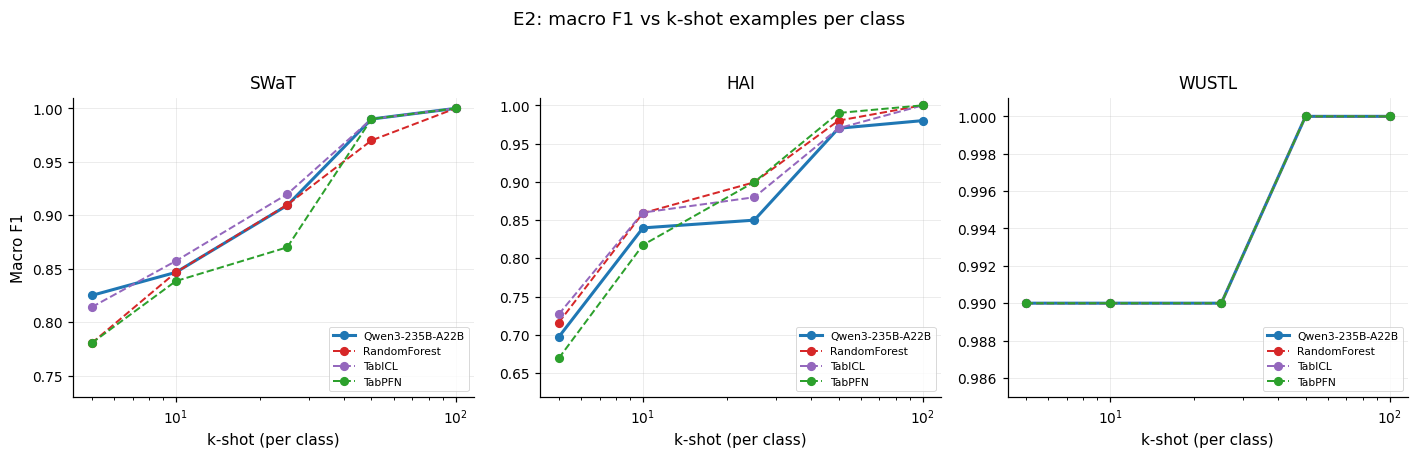

Wrote fig_kshot_scaling.{pdf,png}


In [16]:
# ============================================================
# Figure 6: k-shot scaling -- v2 (per-panel y-axis, WUSTL no longer flat)
# ============================================================
e2_frames = []
for (ds, md_, kind), df in LOADED.items():
    if kind != "e2" or md_ != "binary":
        continue
    df = df.copy()
    df["dataset"] = ds
    e2_frames.append(df)

if e2_frames:
    e2 = pd.concat(e2_frames, ignore_index=True)
    fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(13, 4),
                                sharey=False)   # v2: per-panel y-axis
    if len(DATASET_ORDER) == 1:
        axes = [axes]
    for ax, ds in zip(axes, DATASET_ORDER):
        sub = e2[e2["dataset"] == ds]
        if sub.empty:
            ax.set_visible(False); continue
        for m, g in sub.groupby("model"):
            g = g.sort_values("k")
            color = METHOD_PALETTE.get(m, "#888")
            lw = 2.0 if g["kind"].iloc[0] == "LLM" else 1.3
            ls = "-" if g["kind"].iloc[0] == "LLM" else "--"
            ax.plot(g["k"], g["macro_f1"], ls,
                     color=color, lw=lw, marker="o", markersize=5, label=m)
        ax.set_xscale("log")
        ax.set_xlabel("k-shot (per class)")
        ax.set_ylabel("Macro F1" if ds == DATASET_ORDER[0] else "")
        ax.set_title(DATASET_LABEL[ds], fontsize=11)
        ax.grid(alpha=0.3)
        ax.legend(loc="lower right", fontsize=7)
        # v2: zoom y-axis if all values cluster near 1.0
        f1_min = sub["macro_f1"].min()
        f1_max = sub["macro_f1"].max()
        if f1_min > 0.97:
            ax.set_ylim(f1_min - 0.005, 1.001)
        else:
            ax.set_ylim(max(0, f1_min - 0.05), min(1.01, f1_max + 0.02))
    fig.suptitle("E2: macro F1 vs k-shot examples per class", y=1.03, fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_kshot_scaling.pdf")
    plt.savefig(OUT_DIR / "fig_kshot_scaling.png")
    plt.show()
    print(f"Wrote fig_kshot_scaling.{{pdf,png}}")
else:
    print("No E2 k-shot CSVs found.")


## 13. (Optional) Per-seed MCC dispersion (strip + mean)

If `e7_per_seed_<ds>.csv` is available, draw a strip plot (one dot per seed)
with horizontal mean bar and ±1-std whisker. At n=3 seeds, a violin shape
would be misleading; strip + mean is honest.


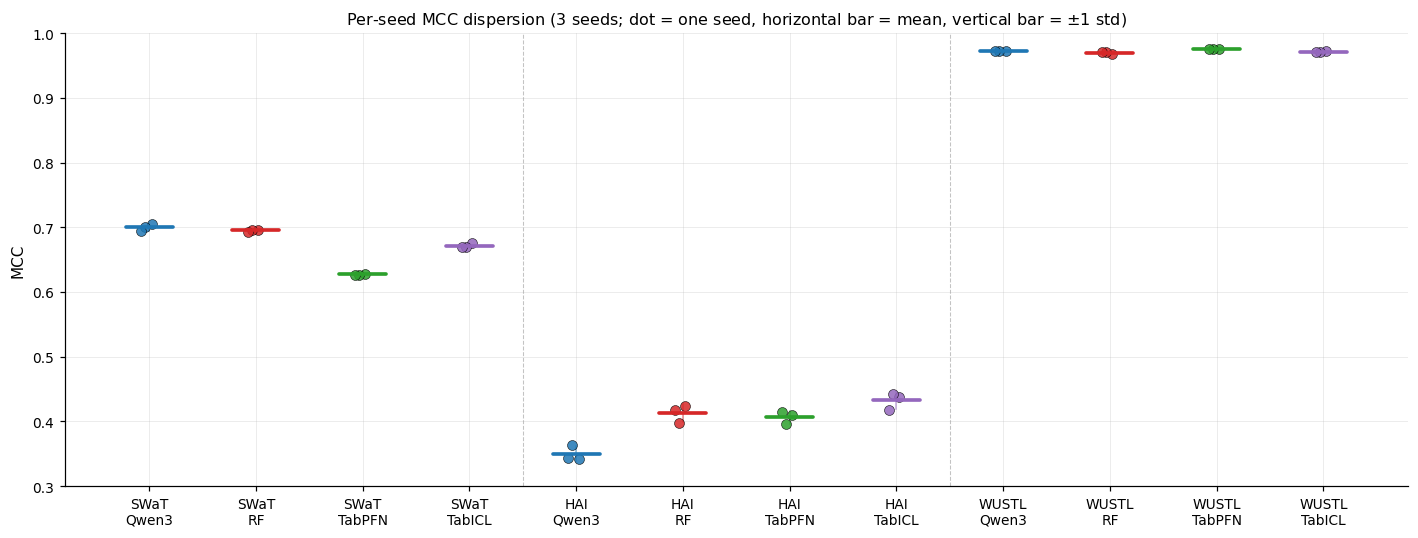

Wrote fig_per_seed_strip.{pdf,png}


In [17]:
# ============================================================
# Figure 7: per-seed dispersion -- v2 (strip + mean, honest at n=3)
# ============================================================
ps_frames = []
for (ds, md_, kind), df in LOADED.items():
    if kind != "e7_per_seed" or md_ != "binary":
        continue
    df = df.copy()
    df["dataset"] = ds
    ps_frames.append(df)

if ps_frames:
    PS = pd.concat(ps_frames, ignore_index=True)
    PS["x_label"] = PS["dataset"].map(DATASET_LABEL) + "\n" + PS["model"]

    # Build the canonical order (dataset blocks, methods in METHOD_ORDER)
    order = []
    for ds in DATASET_ORDER:
        for m in METHOD_ORDER:
            label = DATASET_LABEL[ds] + "\n" + m
            if label in PS["x_label"].values:
                order.append(label)

    fig, ax = plt.subplots(figsize=(13, 5))
    # Strip (one dot per seed) + mean horizontal tick
    for xi, label in enumerate(order):
        sub = PS[PS["x_label"] == label]
        method = label.split("\n")[1]
        color = METHOD_PALETTE.get(method, "#888")
        # Jittered strip
        rng = np.random.default_rng(0)
        jitter = rng.uniform(-0.08, 0.08, size=len(sub))
        ax.scatter(np.full(len(sub), xi) + jitter, sub["MCC"],
                    s=42, color=color, alpha=0.85, edgecolor="black", linewidth=0.4,
                    zorder=3)
        # Horizontal mean bar
        m = sub["MCC"].mean()
        s = sub["MCC"].std(ddof=1) if len(sub) > 1 else 0
        ax.plot([xi - 0.22, xi + 0.22], [m, m],
                 color=color, lw=2.4, zorder=4, solid_capstyle="round")
        # Faint vertical bar = +/- 1 std
        ax.plot([xi, xi], [m - s, m + s], color=color, lw=1.0, alpha=0.55, zorder=2)

    # v2.1: use a short method abbreviation on a separate line + smaller font
    METHOD_SHORT = {"Qwen3-235B-A22B": "Qwen3", "RandomForest": "RF",
                     "TabPFN": "TabPFN", "TabICL": "TabICL"}
    short_labels = []
    for lab in order:
        ds_part, m_part = lab.split("\n")
        short_labels.append(f"{ds_part}\n{METHOD_SHORT.get(m_part, m_part)}")
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(short_labels, rotation=0, ha="center", fontsize=9)
    ax.set_ylabel("MCC")
    ax.set_title("Per-seed MCC dispersion (3 seeds; dot = one seed, "
                  "horizontal bar = mean, vertical bar = $\\pm$1 std)",
                  fontsize=10.5)
    # Light dataset-separator vertical lines
    n_methods = len([m for m in METHOD_ORDER if m in PS["model"].values])
    for sep in range(n_methods, len(order), n_methods):
        ax.axvline(sep - 0.5, color="#aaa", linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_ylim(0.30, 1.00)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_per_seed_strip.pdf")
    plt.savefig(OUT_DIR / "fig_per_seed_strip.png")
    plt.show()
    print(f"Wrote fig_per_seed_strip.{{pdf,png}}")
else:
    print("No e7_per_seed CSVs found.")


## 11b. Cost vs accuracy Pareto for LLMs

`e5_cost_<ds>.csv` records each LLM's USD cost-per-correct-prediction and
its macro F1. The right operating point depends on the deployment budget,
but this figure makes the cost / accuracy frontier explicit.


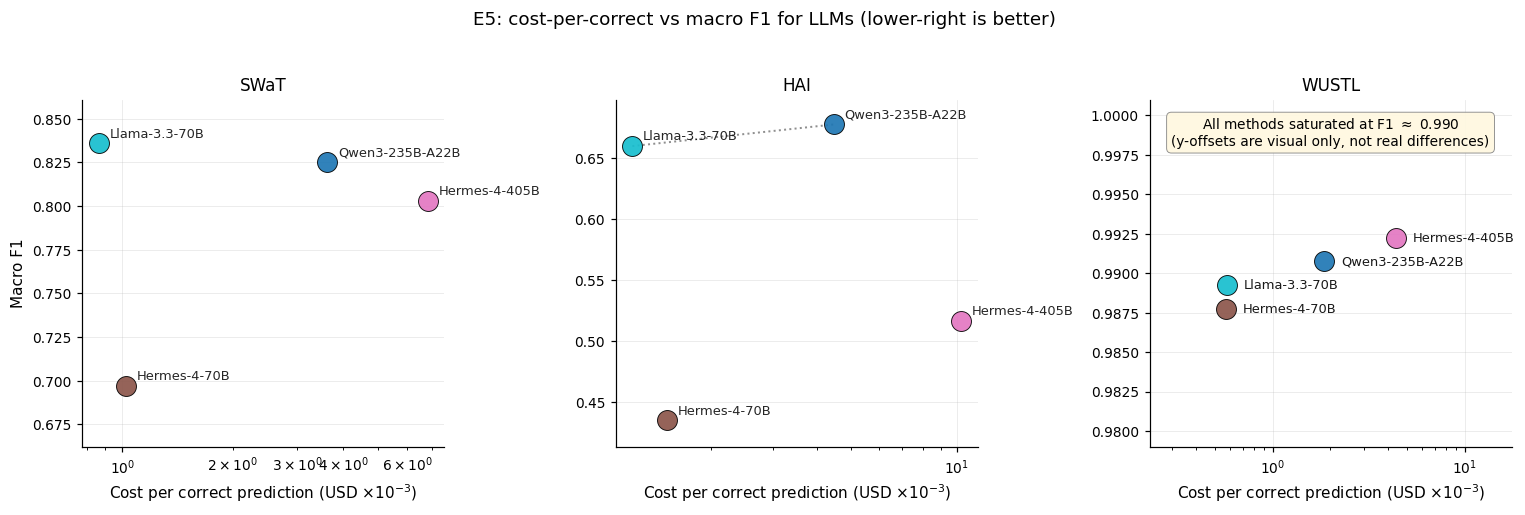

Wrote fig_cost_pareto.{pdf,png}


In [18]:
# ============================================================
# Figure A1: cost-vs-MCC Pareto (LLMs only)
# ============================================================
# v2.5 fix: iterate over the (dataset, mode, base) entries ONCE, not over
# every LOADED key (which previously caused ~10x duplication because the same
# E5 CSV was appended once per (dataset, mode, kind) entry in LOADED).
e5_frames = []
seen_paths = set()
for ds_, md_2, base in INPUT_DIRS:
    if md_2 != "binary": continue
    p = Path(base, "E5_cost", f"e5_cost_{ds_}.csv")
    if not p.exists() or str(p) in seen_paths:
        continue
    seen_paths.add(str(p))
    df5 = pd.read_csv(p)
    df5["dataset"] = ds_
    e5_frames.append(df5)

if e5_frames:
    E5 = pd.concat(e5_frames, ignore_index=True)
    fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(14, 4.5), sharey=False)
    if len(DATASET_ORDER) == 1:
        axes = [axes]
    for ax, ds in zip(axes, DATASET_ORDER):
        sub = E5[E5["dataset"] == ds]
        if sub.empty:
            ax.set_visible(False); continue

        rows = sub.sort_values("cost_per_correct_usd").reset_index(drop=True)
        f1_span = rows["macro_f1"].max() - rows["macro_f1"].min()

        # v2.4: When all methods saturate (sub-0.5pp F1 spread), the scatter
        # becomes label soup. Plot dots at staggered y-offsets and inline-label
        # each one cleanly; add a saturation banner at the top.
        if f1_span < 0.005:
            # Stagger y just for plotting purposes so labels separate vertically,
            # but report the true F1 in the label itself.
            f1_center = rows["macro_f1"].mean()
            n = len(rows)
            for i_row, (_, r) in enumerate(rows.iterrows()):
                color = METHOD_PALETTE.get(r["model"], "#888")
                # Offset alternates around the mean to give each point a visual slot
                y_plot = f1_center + (i_row - (n - 1) / 2) * 0.0015
                ax.scatter(r["cost_per_correct_usd"] * 1000, y_plot,
                            s=170, color=color, edgecolor="black",
                            linewidth=0.6, alpha=0.92, zorder=3)
                ax.annotate(r["model"],
                             (r["cost_per_correct_usd"] * 1000, y_plot),
                             xytext=(11, 0), textcoords="offset points",
                             ha="left", va="center", fontsize=8.5, alpha=0.9)
            ax.set_xscale("log")
            ax.set_xlim(rows["cost_per_correct_usd"].min() * 1000 * 0.4,
                         rows["cost_per_correct_usd"].max() * 1000 * 4.0)
            y_pad = 0.005
            ax.set_ylim(f1_center - n * 0.0015 - y_pad,
                         f1_center + n * 0.0015 + y_pad)
            # Banner annotation
            ax.text(0.5, 0.95,
                     f"All methods saturated at F1 $\\approx$ {f1_center:.3f}\n"
                     "(y-offsets are visual only, not real differences)",
                     transform=ax.transAxes, ha="center", va="top",
                     fontsize=9,
                     bbox=dict(facecolor="#fff8e1", edgecolor="#888",
                                boxstyle="round,pad=0.35", alpha=0.95))
        else:
            for _, r in rows.iterrows():
                color = METHOD_PALETTE.get(r["model"], "#888")
                ax.scatter(r["cost_per_correct_usd"]*1000, r["macro_f1"],
                            s=170, color=color, edgecolor="black", linewidth=0.6,
                            alpha=0.92, zorder=3)
                ax.annotate(r["model"],
                             (r["cost_per_correct_usd"]*1000, r["macro_f1"]),
                             xytext=(7, 4), textcoords="offset points",
                             fontsize=8.5, alpha=0.85)
            # Pareto front
            pts = rows[["cost_per_correct_usd","macro_f1","model"]].sort_values("cost_per_correct_usd")
            frontier = []
            best_f1 = -1
            for _, r in pts.iterrows():
                if r["macro_f1"] > best_f1:
                    frontier.append((r["cost_per_correct_usd"]*1000, r["macro_f1"]))
                    best_f1 = r["macro_f1"]
            if len(frontier) >= 2:
                fx, fy = zip(*frontier)
                ax.plot(fx, fy, ":", color="#333", alpha=0.55, lw=1.3,
                         label="Pareto frontier", zorder=1)
            ax.set_xscale("log")
            f1_min = rows["macro_f1"].min()
            f1_max = rows["macro_f1"].max()
            ax.set_ylim(max(0.0, f1_min * 0.95), min(1.0, f1_max * 1.03))

        ax.set_xlabel("Cost per correct prediction (USD $\\times 10^{-3}$)")
        ax.set_ylabel("Macro F1" if ax is axes[0] else "")
        ax.set_title(f"{DATASET_LABEL[ds]}", fontsize=11)
        ax.grid(alpha=0.3)

    fig.suptitle("E5: cost-per-correct vs macro F1 for LLMs (lower-right is better)",
                 y=1.03, fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_cost_pareto.pdf")
    plt.savefig(OUT_DIR / "fig_cost_pareto.png")
    plt.show()
    print(f"Wrote fig_cost_pareto.{{pdf,png}}")
else:
    print("No E5 cost CSVs available.")


## 11c. R1 cross-seed Mann–Whitney: which LLMs beat RF?

The R1 multi-seed CSVs include `mw_p_vs_RF_f1`: the Mann–Whitney U-test
p-value comparing each LLM's macro-F1 distribution (5 seeds) against the
Random Forest baseline's distribution. A heatmap of these p-values makes
the cross-dataset, cross-LLM significance pattern instantly visible.


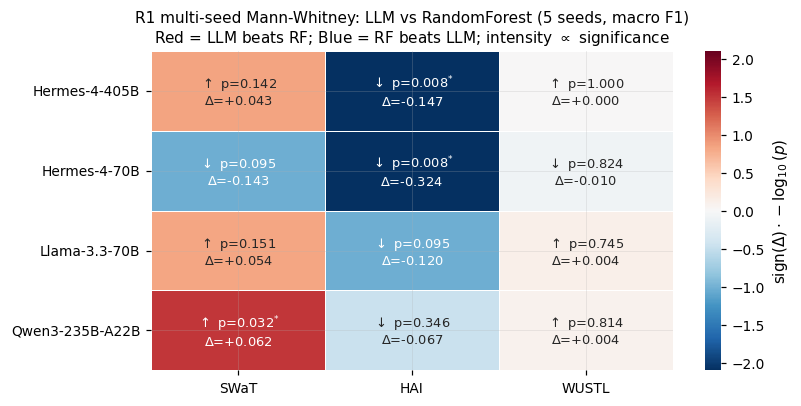

Wrote fig_r1_mannwhitney.{pdf,png}


In [19]:
# ============================================================
# Figure A2: R1 Mann-Whitney p-values vs RF (binary mode)
# ============================================================
r1_frames = []
for (ds, md_, kind), df in LOADED.items():
    if kind != "r1" or md_ != "binary": continue
    df = df.copy()
    df["dataset"] = ds
    r1_frames.append(df)

if r1_frames:
    R1 = pd.concat(r1_frames, ignore_index=True)
    # Keep only LLM rows with a non-null p-value
    R1_llm = R1[R1["kind"] == "LLM"].copy()
    pivot_p = R1_llm.pivot(index="model", columns="dataset",
                            values="mw_p_vs_RF_f1")
    pivot_f1 = R1_llm.pivot(index="model", columns="dataset",
                             values="macro_f1_mean")
    pivot_rf = (R1[R1["kind"] == "Anchor"]
                  .set_index("dataset")["macro_f1_mean"])
    # Compute delta = LLM_f1 - RF_f1 for sign
    pivot_delta = pivot_f1.subtract(pivot_rf, axis=1)

    # Restrict to known datasets in order
    keep = [d for d in DATASET_ORDER if d in pivot_p.columns]
    pivot_p     = pivot_p[keep]
    pivot_delta = pivot_delta[keep]

    # Build annotation: p (3 sig figs) and a directional arrow
    annot = np.empty_like(pivot_p.values, dtype=object)
    for i in range(pivot_p.shape[0]):
        for j in range(pivot_p.shape[1]):
            p = pivot_p.values[i, j]
            d = pivot_delta.values[i, j]
            if np.isnan(p):
                annot[i, j] = "—"
            else:
                arrow = "$\\uparrow$" if d > 0 else "$\\downarrow$"
                p_str = f"{p:.3f}" if p >= 0.001 else "<0.001"
                star  = "$^{*}$" if p < 0.05 else ""
                annot[i, j] = f"{arrow} p={p_str}{star}\n$\\Delta$={d:+.3f}"

    # Color matrix: signed -log10(p), capped, so significance is intensity.
    color_mat = np.zeros_like(pivot_p.values, dtype=float)
    for i in range(pivot_p.shape[0]):
        for j in range(pivot_p.shape[1]):
            p = pivot_p.values[i, j]
            d = pivot_delta.values[i, j]
            if np.isnan(p) or np.isnan(d):
                color_mat[i, j] = np.nan
            else:
                color_mat[i, j] = (1.0 if d > 0 else -1.0) * min(-math.log10(max(p, 1e-10)), 3.5)

    vmax = max(abs(np.nanmin(color_mat)), abs(np.nanmax(color_mat)), 1.5)
    fig, ax = plt.subplots(figsize=(7.5, max(3.0, 0.7 * pivot_p.shape[0] + 1)))
    sns.heatmap(color_mat, annot=annot, fmt="",
                 xticklabels=[DATASET_LABEL[c] for c in pivot_p.columns],
                 yticklabels=pivot_p.index, cmap="RdBu_r", center=0,
                 vmin=-vmax, vmax=vmax, linewidths=0.6, ax=ax,
                 cbar_kws={"label": "$\\mathrm{sign}(\\Delta) \\cdot -\\log_{10}(p)$"},
                 annot_kws={"fontsize": 8.5})
    ax.set_title("R1 multi-seed Mann-Whitney: LLM vs RandomForest (5 seeds, macro F1)\n"
                  "Red = LLM beats RF; Blue = RF beats LLM; intensity $\\propto$ significance",
                  fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_r1_mannwhitney.pdf")
    plt.savefig(OUT_DIR / "fig_r1_mannwhitney.png")
    plt.show()
    print(f"Wrote fig_r1_mannwhitney.{{pdf,png}}")
else:
    print("No R1 CSVs found.")


## 11d. WUSTL per-class delta vs RandomForest

The WUSTL multi-class R2 CSV already encodes each LLM's per-class
F1 minus the RandomForest F1 (`delta_vs_RF`) with a `p_vs_RF` for
significance. A grouped bar plot of the deltas shows which classes the
LLM family wins / loses on, with significance stars.


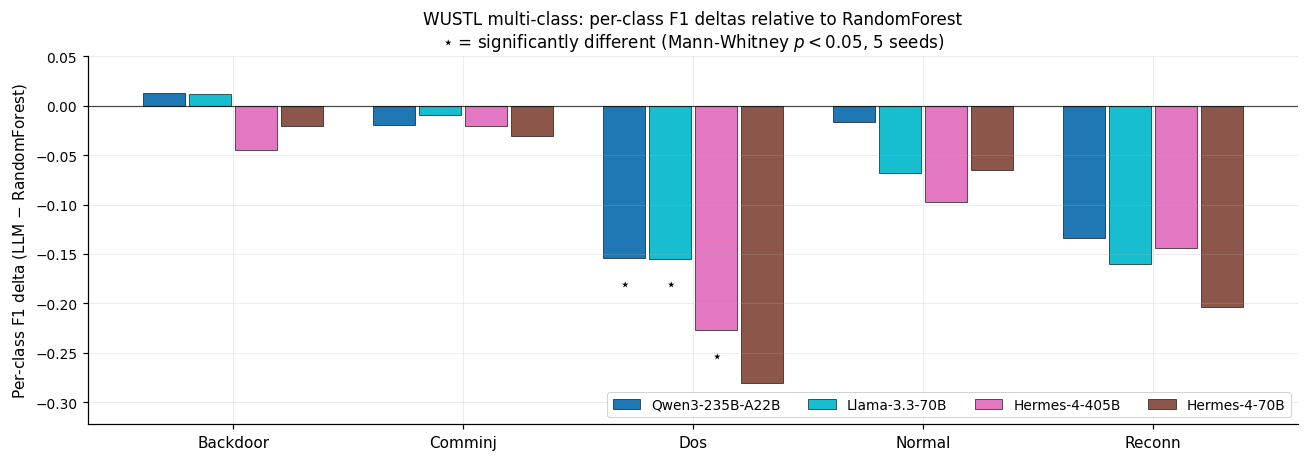

Wrote fig_wustl_delta_vs_rf.{pdf,png}


In [20]:
# ============================================================
# Figure A3: WUSTL multi-class per-class delta (LLM - RF) with significance stars
# ============================================================
wmc_r2 = LOADED.get(("wustl", "multiclass", "r2"))
if wmc_r2 is not None and not wmc_r2.empty:
    df = wmc_r2[wmc_r2["kind"] == "LLM"].copy()
    classes = sorted(df["class"].unique())
    models  = list(df["model"].unique())
    # Order LLM models by overall mean delta (most positive at the top)
    overall = (df.groupby("model")["delta_vs_RF"].mean()
                  .sort_values(ascending=False))
    models = list(overall.index)

    fig, ax = plt.subplots(figsize=(12, max(3.0, 0.7 * len(models) + 1.5)))
    x = np.arange(len(classes))
    bar_w = 0.8 / len(models)
    for mi, m in enumerate(models):
        sub = df[df["model"] == m].set_index("class").reindex(classes)
        deltas = sub["delta_vs_RF"].values
        ps     = sub["p_vs_RF"].values
        color  = METHOD_PALETTE.get(m, "#888")
        positions = x - 0.4 + bar_w * (mi + 0.5)
        bars = ax.bar(positions, deltas, width=bar_w*0.92, color=color, label=m,
                       edgecolor="black", linewidth=0.4)
        # Significance star
        for xi, (d, p) in enumerate(zip(deltas, ps)):
            if not np.isnan(p) and p < 0.05:
                ax.text(positions[xi], d + (0.005 if d >= 0 else -0.015),
                         "$\\star$", ha="center", va="bottom" if d >= 0 else "top",
                         fontsize=11, color="black", fontweight="bold")
    ax.axhline(0, color="black", lw=0.8, alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(classes, fontsize=10)
    ax.set_ylabel("Per-class F1 delta (LLM $-$ RandomForest)")
    ax.set_title("WUSTL multi-class: per-class F1 deltas relative to RandomForest\n"
                  "$\\star$ = significantly different (Mann-Whitney $p<0.05$, 5 seeds)",
                  fontsize=11)
    ax.legend(loc="lower right", fontsize=9, ncol=len(models),
               frameon=True, framealpha=0.95)
    ax.grid(axis="y", alpha=0.3)
    # Tidy y-axis
    ymin = min(0.0, df["delta_vs_RF"].min() * 1.15)
    ymax = max(0.05, df["delta_vs_RF"].max() * 1.20)
    ax.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_wustl_delta_vs_rf.pdf")
    plt.savefig(OUT_DIR / "fig_wustl_delta_vs_rf.png")
    plt.show()
    print(f"Wrote fig_wustl_delta_vs_rf.{{pdf,png}}")
else:
    print("No WUSTL multi-class r2 CSV found.")


## 14. Summary

All paper artifacts written to `OUT_DIR`. If you keep the directory layout
consistent for the next round of experiments, re-running this notebook will
overwrite everything with the latest numbers — no edits needed.

### LaTeX tables (4)

| Artifact | Source data |
|---|---|
| `paper_master_table.csv` | all `master_summary_*.csv` |
| `paper_headline_table_binary.tex` | E7 multiseed (binary) |
| `paper_mcnemar_table.tex` | E7 paired McNemar (binary) |
| `paper_wustl_multiclass_e7.tex` | WUSTL E7 multiseed (multiclass) |
| `paper_perclass_wustl_multiclass.tex` | WUSTL R2 perclass (multiclass) |

### Figures (10, each as both PDF for the paper and PNG for review)

| Figure | Source | Section |
|---|---|---|
| `fig_forest_headline.{pdf,png}` | E7 multiseed | §5 |
| `fig_far_dr_pareto.{pdf,png}` | E7 multiseed | §6 |
| `fig_mcnemar_heatmap.{pdf,png}` | E7 paired McNemar | §7 |
| `fig_wustl_perclass_radar.{pdf,png}` | WUSTL R2 perclass | §9 |
| `fig_cross_method_heatmap.{pdf,png}` | E7 multiseed | §10 |
| `fig_auroc_auprc_bars.{pdf,png}` | E7 AUROC/AUPRC | §11 |
| `fig_cost_pareto.{pdf,png}` | E5 cost | §11b |
| `fig_r1_mannwhitney.{pdf,png}` | R1 multiseed | §11c |
| `fig_wustl_delta_vs_rf.{pdf,png}` | WUSTL R2 perclass | §11d |
| `fig_kshot_scaling.{pdf,png}` | E2 k-shot (optional) | §12 |
| `fig_per_seed_strip.{pdf,png}` | E7 per-seed (optional) | §13 |


In [21]:
# ============================================================
# Final listing of artifacts
# ============================================================
print("Artifacts in", OUT_DIR.resolve())
for f in sorted(OUT_DIR.iterdir()):
    sz = f.stat().st_size
    print(f"  {f.name:<48}  ({sz/1024:.1f} KB)")


Artifacts in /content/paper_artifacts
  fig_auroc_auprc_bars.pdf                          (17.3 KB)
  fig_auroc_auprc_bars.png                          (199.5 KB)
  fig_cost_pareto.pdf                               (19.9 KB)
  fig_cost_pareto.png                               (314.2 KB)
  fig_cross_method_heatmap.pdf                      (16.2 KB)
  fig_cross_method_heatmap.png                      (135.7 KB)
  fig_far_dr_pareto.pdf                             (20.4 KB)
  fig_far_dr_pareto.png                             (298.4 KB)
  fig_forest_headline.pdf                           (23.1 KB)
  fig_forest_headline.png                           (149.5 KB)
  fig_kshot_scaling.pdf                             (21.8 KB)
  fig_kshot_scaling.png                             (295.4 KB)
  fig_mcnemar_heatmap.pdf                           (21.8 KB)
  fig_mcnemar_heatmap.png                           (133.9 KB)
  fig_per_seed_strip.pdf                            (19.6 KB)
  fig_per_seed_strip.png 

In [22]:
# ============================================================
# 15) DOWNLOAD ALL ARTIFACTS AS A SINGLE ZIP
# ============================================================
# Bundles every file in OUT_DIR (tables, figures, master CSV) into one zip
# and triggers a browser download. Works on Colab, classic Jupyter, and
# JupyterLab; in any other environment it prints the local path so you can
# copy it out manually.
import shutil
import zipfile
from datetime import datetime
from pathlib import Path

# 1) Build the zip from OUT_DIR contents
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = Path(f"ot_ics_ids_paper_artifacts_{ts}.zip")

files_to_zip = sorted(p for p in OUT_DIR.iterdir() if p.is_file())
if not files_to_zip:
    raise FileNotFoundError(
        f"No files in {OUT_DIR.resolve()}. Run the earlier cells first."
    )

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in files_to_zip:
        zf.write(f, arcname=f.name)

size_mb = zip_path.stat().st_size / (1024 * 1024)
print(f"Zipped {len(files_to_zip)} file(s) into {zip_path}  ({size_mb:.2f} MB)")
for f in files_to_zip:
    print(f"  {f.name}  ({f.stat().st_size/1024:.1f} KB)")

# 2) Trigger the appropriate download mechanism
download_method = None
try:
    # Google Colab
    from google.colab import files as _colab_files   # type: ignore
    _colab_files.download(str(zip_path))
    download_method = "Google Colab download triggered"
except ImportError:
    pass

if download_method is None:
    # Classic Jupyter / JupyterLab: render a clickable link
    try:
        from IPython.display import FileLink, display
        display(FileLink(str(zip_path)))
        download_method = "Click the link above to download (Jupyter / JupyterLab)"
    except Exception:
        pass

if download_method is None:
    # Headless: just print the absolute path
    download_method = f"Local file ready at: {zip_path.resolve()}"

print(f"\n{download_method}")

Zipped 27 file(s) into ot_ics_ids_paper_artifacts_20260524_200410.zip  (2.20 MB)
  fig_auroc_auprc_bars.pdf  (17.3 KB)
  fig_auroc_auprc_bars.png  (199.5 KB)
  fig_cost_pareto.pdf  (19.9 KB)
  fig_cost_pareto.png  (314.2 KB)
  fig_cross_method_heatmap.pdf  (16.2 KB)
  fig_cross_method_heatmap.png  (135.7 KB)
  fig_far_dr_pareto.pdf  (20.4 KB)
  fig_far_dr_pareto.png  (298.4 KB)
  fig_forest_headline.pdf  (23.1 KB)
  fig_forest_headline.png  (149.5 KB)
  fig_kshot_scaling.pdf  (21.8 KB)
  fig_kshot_scaling.png  (295.4 KB)
  fig_mcnemar_heatmap.pdf  (21.8 KB)
  fig_mcnemar_heatmap.png  (133.9 KB)
  fig_per_seed_strip.pdf  (19.6 KB)
  fig_per_seed_strip.png  (116.9 KB)
  fig_r1_mannwhitney.pdf  (22.6 KB)
  fig_r1_mannwhitney.png  (185.5 KB)
  fig_wustl_delta_vs_rf.pdf  (20.2 KB)
  fig_wustl_delta_vs_rf.png  (141.2 KB)
  fig_wustl_perclass_radar.pdf  (19.3 KB)
  fig_wustl_perclass_radar.png  (427.7 KB)
  paper_headline_table_binary.tex  (2.1 KB)
  paper_master_table.csv  (23.4 KB)
  paper_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Google Colab download triggered
